In [2]:
from google.colab import files

uploaded = files.upload()

Saving gia_nha.csv to gia_nha.csv


In [ ]:
#Bài 1

import pandas as pd
#Đọc dữ liệu
df = pd.read_csv("gia_nha.csv")
#Lọc các căn hộ có diện tích lớn hơn 100 m2
nhom_lon = df[df["dien_tich"] > 100]
#Đếm số căn
so_can = len(nhom_lon)
#Tính giá trung bình
gia_trung_binh = nhom_lon["gia"].mean()
#In kết quả
print(f"So can ho co dien tich lon hon 100 m2: {so_can}")
print(f"Gia trung binh cua nhom nay: {gia_trung_binh:.3f} ty dong")

#Có 10 căn hộ có diện tích lớn hơn 100 m² Giá trung bình của nhóm căn hộ này là 8.962 tỷ đồng

So can ho co dien tich lon hon 100 m2: 10
Gia trung binh cua nhom nay: 8.962 ty dong


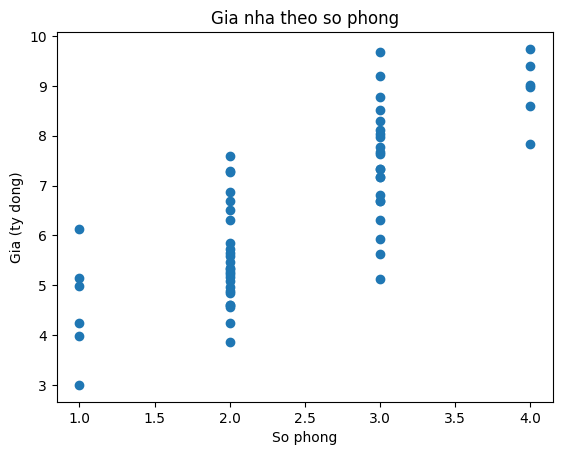

In [ ]:
#Bài 2

import pandas as pd
import matplotlib.pyplot as plt
#Đọc dữ liệu
df = pd.read_csv("gia_nha.csv")
#Vẽ biểu đồ phân tán
plt.scatter(df["so_phong"], df["gia"])
#Đặt tên trục
plt.xlabel("So phong")
plt.ylabel("Gia (ty dong)")
#Đặt tiêu đề
plt.title("Gia nha theo so phong")
#Lưu hình
plt.savefig("bai2.png", dpi=150)
#Hiển thị hình
plt.show()

#Nhận xét: Khi số phòng tăng, giá nhà nhìn chung có xu huớng tăng.

In [ ]:
#Bài 3

import pandas as pd
#Đọc dữ liệu
df = pd.read_csv("gia_nha.csv")
#Biến đầu vào và biến cần dự đoán
x = df["tuoi_nha"].to_numpy()
y = df["gia"].to_numpy()
#Tính giá trị trung bình
x_tb = x.mean()
y_tb = y.mean()
#Công thức bình phương tối thiểu
w = ((x - x_tb) * (y - y_tb)).sum() / ((x - x_tb) ** 2).sum()
b = y_tb - w * x_tb
#In kết quả
print(f"w = {w:.6f}")
print(f"b = {b:.6f}")

#w mang dấu âm khi tuổi nhà tăng thì giá nhà có xu hướng giảm.

w = -0.037858
b = 6.983593


In [3]:
#Bài 4

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
#Đọc dữ liệu
df = pd.read_csv("gia_nha.csv")
#Hai biến đầu vào
X = df[["dien_tich", "so_phong"]]
y = df["gia"]
#Chia dữ liệu thành tập học và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
#Tạo mô hình
mo_hinh = LinearRegression()
#Huấn luyện
mo_hinh.fit(X_train, y_train)
#Dự đoán
y_du_doan = mo_hinh.predict(X_test)
#Tính R2
r2 = r2_score(y_test, y_du_doan)
#In kết quả
print(f"R2 tren tap kiem tra = {r2:.4f}")
print("So sanh:")
print("R2 mo hinh mot bien = 0.9622")
print(f"R2 mo hinh hai bien = {r2:.4f}")

#Mô hình sử dụng hai biến dien_tich và so_phong có R² = 0.9698, cao hơn mô hình một biến có R² = 0.9622. Điều này cho thấy việc thêm biến so_phong giúp mô hình giải thích dữ liệu tốt hơn trên tập kiểm tra.

R2 tren tap kiem tra = 0.9698
So sanh:
R2 mo hinh mot bien = 0.9622
R2 mo hinh hai bien = 0.9698


In [ ]:
#Bài 5
import numpy as np
import pandas as pd
#Đọc dữ liệu
df = pd.read_csv("gia_nha.csv")
#Lấy diện tích và giá
x_goc = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()
#Chuẩn hóa dữ liệu
x_tb = x_goc.mean()
x_do_lech = x_goc.std()
x = (x_goc - x_tb) / x_do_lech
#Khởi tạo
w, b = 0.0, 0.0
#tốc độ học = 0.001
toc_do_hoc = 0.001
so_vong = 200
n = len(x)
for vong in range(1, so_vong + 1):
    #Dự đoán
    y_du_doan = w * x + b
    #Sai số
    chenh_lech = y_du_doan - y
    #Gradient
    grad_w = (2 / n) * (chenh_lech * x).sum()
    grad_b = (2 / n) * chenh_lech.sum()
    #Cập nhật w và b
    w -= toc_do_hoc * grad_w
    b -= toc_do_hoc * grad_b
    #Tính MSE
    if vong == 200:
        mse = (((w * x + b) - y) ** 2).mean()
        print("Tốc độ học:", toc_do_hoc)
        print("MSE vòng 200:", mse)

Tốc độ học: 0.001
MSE vòng 200: 20.21752082045601


In [ ]:
import numpy as np
import pandas as pd
#Đọc dữ liệu
df = pd.read_csv("gia_nha.csv")
#Lấy diện tích và giá
x_goc = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()
#Chuẩn hóa dữ liệu
x_tb = x_goc.mean()
x_do_lech = x_goc.std()
x = (x_goc - x_tb) / x_do_lech
#Khởi tạo
w, b = 0.0, 0.0
#Tốc độ học = 1.02
toc_do_hoc = 1.02
so_vong = 200
n = len(x)
for vong in range(1, so_vong + 1):
    #Dự đoán
    y_du_doan = w * x + b
    #Sai số
    chenh_lech = y_du_doan - y
    #Gradient
    grad_w = (2 / n) * (chenh_lech * x).sum()
    grad_b = (2 / n) * chenh_lech.sum()
    #Cập nhật w và b
    w -= toc_do_hoc * grad_w
    b -= toc_do_hoc * grad_b
    #Tính MSE
    if vong == 200:
        mse = (((w * x + b) - y) ** 2).mean()
        print("Tốc độ học:", toc_do_hoc)
        print("MSE vòng 200:", mse)

Tốc độ học: 1.02
MSE vòng 200: 290391782.0192286


Khi tốc độ học bằng 0.001, mỗi bước cập nhật rất nhỏ nên thuật toán hội tụ chậm và sau 200 vòng lặp MSE vẫn còn lớn. Khi tốc độ học bằng 1.02, bước cập nhật quá lớn làm thuật toán vượt qua điểm tối ưu, khiến MSE tăng rất mạnh. Vì vậy tốc độ học cần được chọn phù hợp; quá nhỏ thì học chậm, quá lớn thì thuật toán có thể không hội tụ.

In [ ]:
#Bài 6
#Hệ số của mô hình
w = 0.078367
b = 0.401752
def du_doan_gia(dien_tich):
    #Kiểm tra diện tích có nằm ngoài khoảng dữ liệu hay không
    if dien_tich < 35.5 or dien_tich > 117.5:
        print("Canh bao: Dien tich nam ngoai khoang du lieu da hoc.")
    #Công thức dự đoán
    gia_du_doan = w * dien_tich + b
    return gia_du_doan
#Gọi hàm với 3 giá trị
print(f"Dien tich 60 m2 -> {du_doan_gia(60):.3f} ty dong")
print(f"Dien tich 80 m2 -> {du_doan_gia(80):.3f} ty dong")
print(f"Dien tich 200 m2 -> {du_doan_gia(200):.3f} ty dong")

Dien tich 60 m2 -> 5.104 ty dong
Dien tich 80 m2 -> 6.671 ty dong
Canh bao: Dien tich nam ngoai khoang du lieu da hoc.
Dien tich 200 m2 -> 16.075 ty dong


Khoảng diện tích mà dữ liệu đã học là từ 35.5 m² đến 117.5 m². Diện tích 200 m² nằm ngoài khoảng này nên chương trình phải đưa ra cảnh báo.